<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/Practical_03(PR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = {
    'Email':[
        "Congratulations! You won a free iPhone",
        "Meeting scheduled tomorrow at 10 AM",
        "Claim your lottery prize now",
        "Project report submission deadline",
        "Win cash reward today",
        "Please find the attached assignment",
        "Exclusive offer just for you",
        "Let's have lunch tomorrow",
        "Get free coupons instantly",
        "Your interview is confirmed"
    ],
    'Label':[
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham"
    ]
}

df = pd.DataFrame(data)

df

,Email,Label
0,Congratulations! You won a free iPhone,Spam
1,Meeting scheduled tomorrow at 10 AM,Ham
2,Claim your lottery prize now,Spam
3,Project report submission deadline,Ham
4,Win cash reward today,Spam
5,Please find the attached assignment,Ham
6,Exclusive offer just for you,Spam
7,Let's have lunch tomorrow,Ham
8,Get free coupons instantly,Spam
9,Your interview is confirmed,Ham


In [3]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['Email'])

y = df['Label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [5]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [6]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Spam' 'Ham' 'Ham']


In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy*100,"%")

Accuracy: 100.0 %


[[2 0]
 [0 1]]


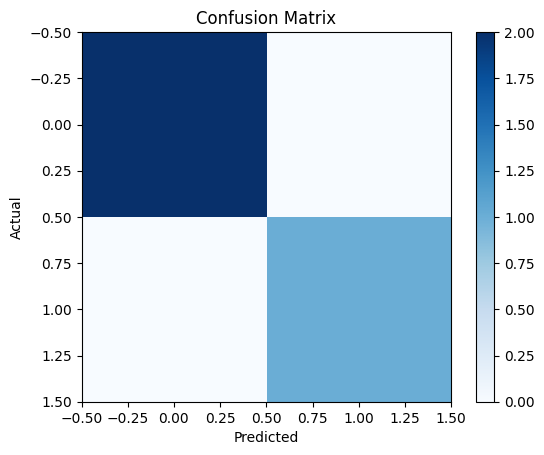

In [8]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [10]:
feature_names = vectorizer.get_feature_names_out()

spam_prob = model.feature_log_prob_[list(model.classes_).index('Spam')]

top_spam = np.argsort(spam_prob)[-10:]

print("Top Spam Words:\n")

for i in reversed(top_spam):
    print(feature_names[i])

Top Spam Words:

you
your
won
win
today
reward
lottery
now
offer
prize


In [11]:
new_email = ["Congratulations! Claim your free lottery prize now"]

new_data = vectorizer.transform(new_email)

prediction = model.predict(new_data)

print("Prediction:", prediction[0])

Prediction: Spam
